<a href="https://colab.research.google.com/github/HISATAKA-KATO/EU_M_Math-Repository/blob/main/Chap09_Ex_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

相関係数0.889:


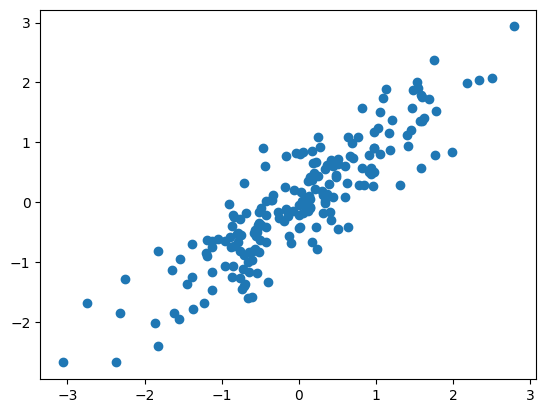

In [16]:
from sklearn.preprocessing import StandardScaler
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import pandas as pd

#Randam state オブジェクトを作成
sample = np.random.RandomState(1)

#二つの乱数を生成
X = np.dot(sample.rand(2,2),sample.randn(2,200)).T

#標準化
sc = StandardScaler()
X_std = sc.fit_transform(X)

#相関係数の算出とグラフ化
print('相関係数{:.3f}:'.format(sp.stats.pearsonr(X_std[:,0],X_std[:,1])[0]))
plt.scatter(X_std[:,0],X_std[:,1])

[[ 0.70710678  0.70710678]
 [ 0.70710678 -0.70710678]]

各主成分の分数:[1.89888438 0.11116588]

各主成分の分数割合:[0.94469498 0.05530502]


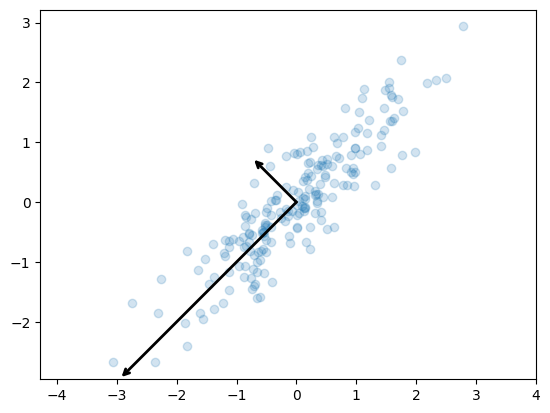

In [17]:
from sklearn.decomposition import PCA

#主成分分析
pca = PCA(n_components=2)
pca.fit(X_std)

print(pca.components_)

print('\n各主成分の分数:{}'.format(pca.explained_variance_))
print('\n各主成分の分数割合:{}'.format(pca.explained_variance_ratio_))

#パラメータ設定
arrowprops = dict(arrowstyle='->',linewidth=2,shrinkA=0,shrinkB=0)

#矢印を書くための関数
def draw_vector(v0,v1):
    plt.gca().annotate('',v1,v0, arrowprops=arrowprops)

#元のデータをプロット
plt.scatter(X_std[:,0],X_std[:,1],alpha=0.2)

#主成分分析の2軸を矢印で表示する
for length, vector in zip(pca.explained_variance_,pca.components_):
    v = -vector * 3 * np.sqrt(length)
    draw_vector(pca.mean_,pca.mean_ + v)

plt.axis('equal');

In [18]:
from sklearn.datasets import load_iris
iris = load_iris()

sc = StandardScaler()
X_std = sc.fit_transform(iris.data)

pca = PCA(n_components=2)
pca.fit(X_std)
X_pca = pca.transform(X_std)

print('X_pca shape:{}'.format(X_pca.shape))
print('Explained variance ratio:{}'.format(pca.explained_variance_ratio_))


X_pca shape:(150, 2)
Explained variance ratio:[0.72962445 0.22850762]


In [19]:
#列にラベルを付ける、一つ目が第一主成分
X_pca = pd.DataFrame(X_pca,columns=['pc1','pc2'])
X_pca['target'] = iris.target
X_pca.head()


,pc1,pc2,target
0,-2.264703,0.480027,0
1,-2.080961,-0.674134,0
2,-2.364229,-0.341908,0
3,-2.299384,-0.597395,0
4,-2.389842,0.646835,0


X_pca shape:(569, 2)
Explained variance ratio:[0.44272026 0.18971182]


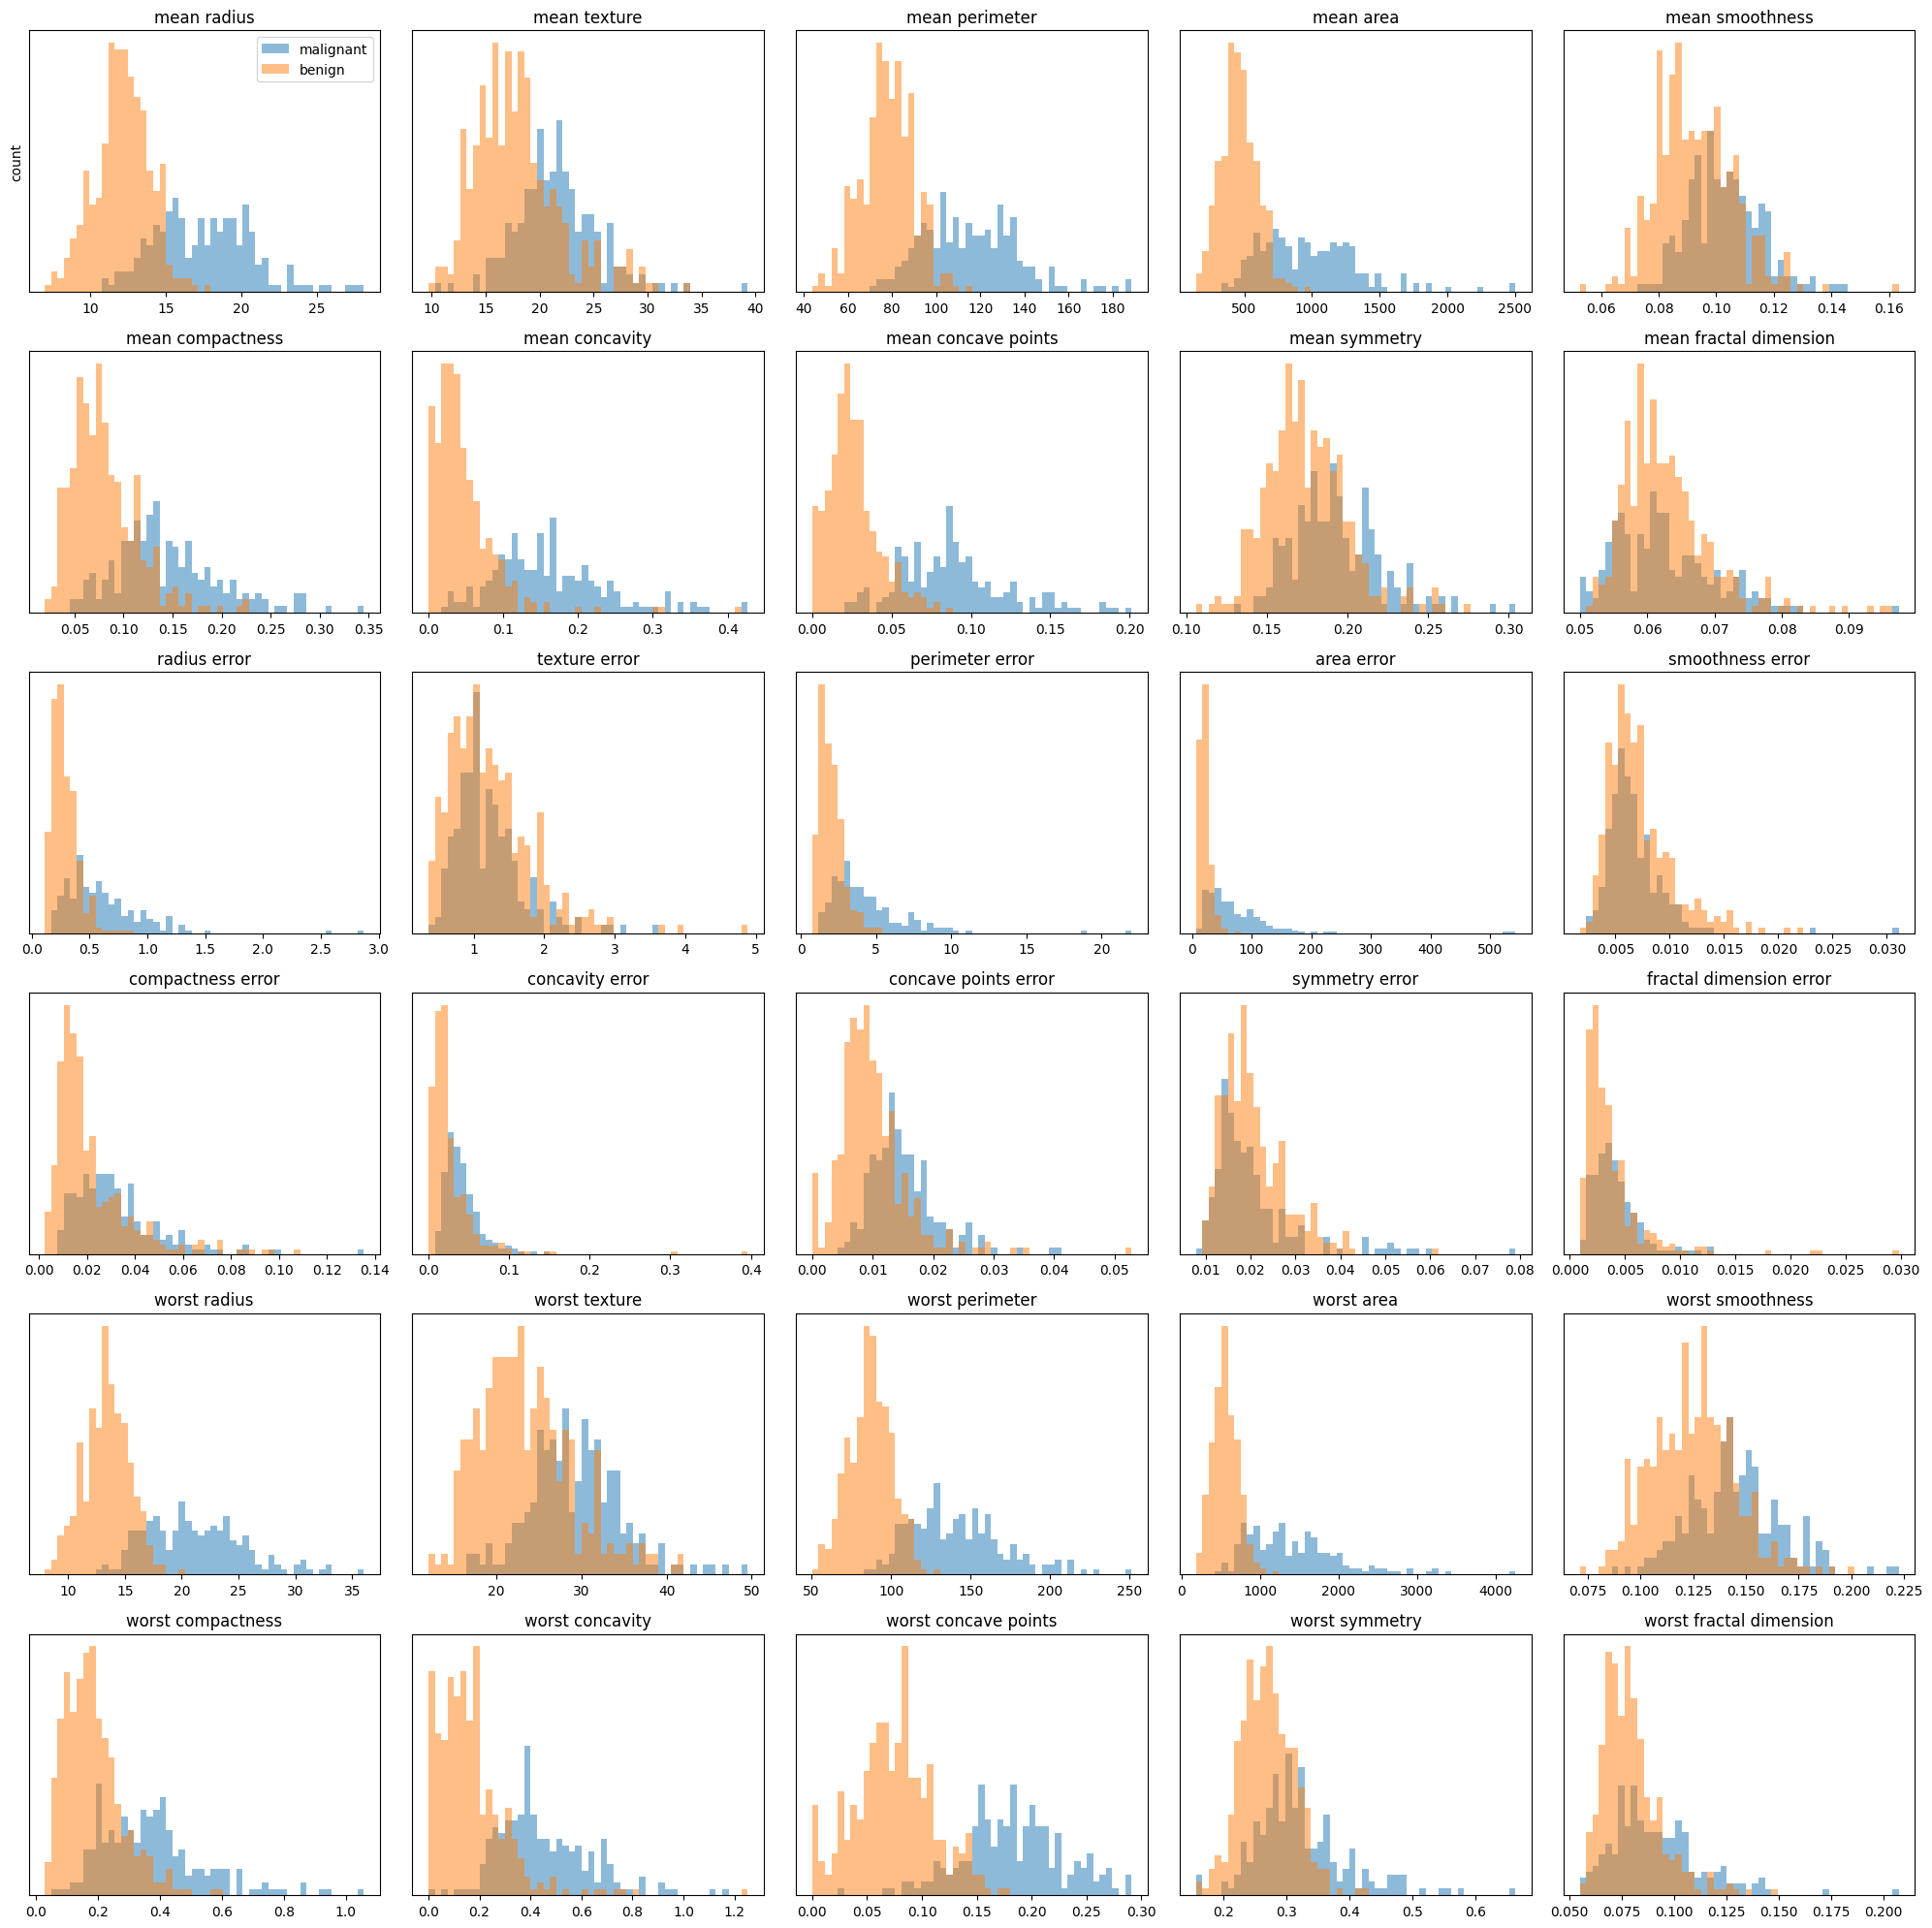

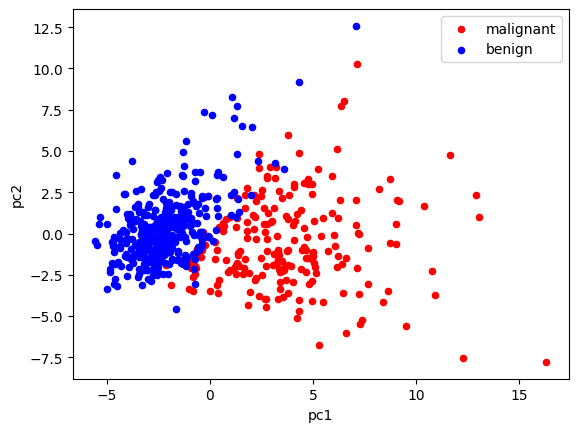

In [23]:
#乳がんのデータをインポート
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()

#データを悪性か良性かに分けるためのフィルター処理
malignant = cancer.data[cancer.target == 0]#悪性
benign = cancer.data[cancer.target == 1]#良性

#maligantがブルー,beginがオレンジのヒストグラム
#各図は、各々の説明変数(mean radiusなど)と目的変数との関係を示したヒストグラム
fig,axes = plt.subplots(6,5,figsize=(20,20))
ax = axes.ravel()
for i in range(30):
    _,bins = np.histogram(cancer.data[:,i],bins=50)
    ax[i].hist(malignant[:,i],bins=bins,alpha=0.5)
    ax[i].hist(benign[:,i],bins=bins,alpha=0.5)
    ax[i].set_title(cancer.feature_names[i])
    ax[i].set_yticks(())

ax[0].set_ylabel('count')
ax[0].legend(['malignant','benign'],loc='best')
fig.tight_layout()

#標準化
sc = StandardScaler()
X_std = sc.fit_transform(cancer.data)

#主成分分析
pca = PCA(n_components=2)
pca.fit(X_std)
X_pca = pca.transform(X_std)

#表示
print('X_pca shape:{}'.format(X_pca.shape))
print('Explained variance ratio:{}'.format(pca.explained_variance_ratio_))

#列にラベルを付ける、一つ目が第一主成分、二つ目が第二主成分
X_pca = pd.DataFrame(X_pca,columns=['pc1','pc2'])
X_pca = pd.concat([X_pca,pd.DataFrame(cancer.target, columns=['target'])],axis=1)

#悪性、良性を分ける
pca_malignant = X_pca[X_pca['target'] == 0]
pca_benign = X_pca[X_pca['target'] == 1]

#悪性と良性をプロット
ax = pca_malignant.plot.scatter(x='pc1',y='pc2',color='red',label='malignant');
pca_benign.plot.scatter(x='pc1',y='pc2',color='blue',label='benign',ax=ax);

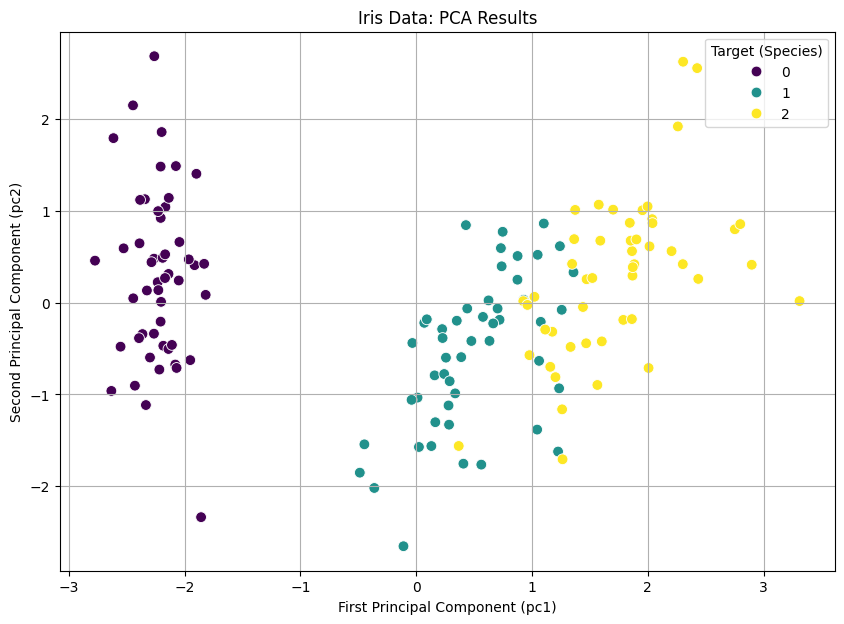

In [20]:
import seaborn as sns

# プロットのサイズ設定
plt.figure(figsize=(10, 7))

# ターゲットごとに色分けしてプロット
sns.scatterplot(x='pc1', y='pc2', hue='target', data=X_pca, palette='viridis', s=60)

plt.title('Iris Data: PCA Results')
plt.xlabel('First Principal Component (pc1)')
plt.ylabel('Second Principal Component (pc2)')
plt.legend(title='Target (Species)', loc='best')
plt.grid(True)
plt.show()

#考察

1. **データの分離**： グラフから、第1主成分（pc1）の値によって、ターゲット（アヤメの種類）が比較的きれいに分離されていることがわかります。特に、ある1つのクラス（target=0）は、他の2つのクラスからpc1の軸上で大きく離れて存在しています。
2. **次元圧縮の効果**：Explained variance ratioを見ると、第1主成分と第2主成分だけで全分散の約95%以上（約73% + 23%）を説明できており、4次元あった元のデータを2次元に落としても、情報の損失を最小限に抑えつつ分類に有用な特徴を抽出できていることがわかります。
